In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import sys
import os

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data.classification.generator import ClassificationDataGenerator
from src.data.common.base_generator import GeneratorConfig

# Hardware Check

In [5]:
print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("No GPU detected. Training will proceed on CPU (this may be slow).")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU Name: Tesla T4
GPU Memory: 14.56 GB


# Data generation

In [6]:
gen = ClassificationDataGenerator()
config = GeneratorConfig.Presets.balanced()

num_samples = 2000
n_workers = os.cpu_count()
X_spectra, y_labels = gen.generate_dataset(num_samples=num_samples, min_elements=1, max_elements=5, config=config, num_workers=n_workers)

print(f"Generated data shape X_spectra: {X_spectra.shape}")
print(f"Generated data shape y_labels: {y_labels.shape}")

Starting parallel classification generation with 2 workers...


Parallel Classification Generation: 100%|██████████| 2000/2000 [21:40<00:00,  1.54it/s]


Generated data shape X_spectra: (2000, 600)
Generated data shape y_labels: (2000, 41)


# Train/Val/Test Split

In [7]:
indices = np.arange(num_samples)
np.random.shuffle(indices)
X_spectra = X_spectra[indices]
y_labels = y_labels.iloc[indices].reset_index(drop=True)

train_split = int(0.7 * num_samples)
val_split = int(0.85 * num_samples)

X_train, y_train = X_spectra[:train_split], y_labels[:train_split]
X_val, y_val     = X_spectra[train_split:val_split], y_labels[train_split:val_split]
X_test, y_test   = X_spectra[val_split:], y_labels[val_split:]

print(f"Train size: {X_train.shape[0]}")
print(f"Val size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 1400
Val size: 300
Test size: 300


# Experimental Grid & Training

In [9]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from src.models.classification.architectures import MLPClassifier, CNNClassifier, TransformerClassifier
from src.models.denoising.preprocessing import StandardScaler, MinMaxScaler, LogMinMaxScaler
from xgboost import XGBClassifier

preprocessing_strategies = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'LogMinMax': LogMinMaxScaler()
}

architectures = {
    # Machine Learning
    'RandomForest': MultiOutputClassifier(RandomForestClassifier()),
    'AdaBoost': MultiOutputClassifier(AdaBoostClassifier()),
    'XGBoost': MultiOutputClassifier(XGBClassifier(use_label_encoder=False, eval_metric='logloss')),

    # Deep Learning
    'MLP': MLPClassifier,
    'CNN': CNNClassifier,
    'Transformer': TransformerClassifier
}

results = {}
trained_models = {}

In [10]:
from sklearn.metrics import f1_score, precision_score, recall_score
from src.models.classification.trainer import ClassificationTrainer
import torch

epochs = 100
batch_size = 64
patience = 15
input_dim = X_train.shape[1]
num_classes = y_train.shape[1]

for prep_name, scaler in preprocessing_strategies.items():
    print(f"\n{'='*40}\nPreprocessing Strategy: {prep_name}\n{'='*40}")

    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)

    y_train_np = y_train.values.astype(np.float32)
    y_val_np = y_val.values.astype(np.float32)
    y_test_np = y_test.values.astype(np.float32)

    for arch_name, arch_item in architectures.items():
        print(f"--> Training: {arch_name}")

        if arch_name in ['RandomForest', 'AdaBoost', 'XGBoost']:
            model = arch_item
            model.fit(X_train_s, y_train_np)
            preds = (model.predict(X_test_s) > 0.5).astype(int)
            history = None

        else:
            model = arch_item(input_dim=input_dim, num_classes=num_classes)
            trainer = ClassificationTrainer(model=model)

            # Training
            history = trainer.train(
                X_train_s, y_train_np,
                X_val_s, y_val_np,
                epochs=epochs,
                batch_size=batch_size,
                patience=patience
            )

            model.eval()
            with torch.no_grad():
                X_test_t = torch.FloatTensor(X_test_s).to(trainer.device)
                raw_preds = model(X_test_t).cpu().numpy()
                preds = (raw_preds > 0.5).astype(int)

        f1 = f1_score(y_test_np, preds, average='weighted', zero_division=0)
        precision = precision_score(y_test_np, preds, average='weighted', zero_division=0)
        recall = recall_score(y_test_np, preds, average='weighted', zero_division=0)

        results[f"{prep_name}_{arch_name}"] = {
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'history': history,
        }
        trained_models[f"{prep_name}_{arch_name}"] = (model, scaler)
        print(f"F1-Score: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")


Preprocessing Strategy: Standard
--> Training: RandomForest
F1-Score: 0.7143 | Precision: 0.9765 | Recall: 0.6319
--> Training: AdaBoost
F1-Score: 0.7795 | Precision: 0.8524 | Recall: 0.7340
--> Training: XGBoost
F1-Score: 0.8115 | Precision: 0.9104 | Recall: 0.7611
--> Training: MLP


Training:  29%|██▉       | 29/100 [00:02<00:06, 11.42it/s, train_loss=0.0484, val_loss=0.1771]



Early stopping triggered at epoch 30
F1-Score: 0.5882 | Precision: 0.9100 | Recall: 0.4625
--> Training: CNN


Training:  35%|███▌      | 35/100 [00:03<00:07,  9.06it/s, train_loss=0.0359, val_loss=0.1610]



Early stopping triggered at epoch 36
F1-Score: 0.6651 | Precision: 0.8876 | Recall: 0.5570
--> Training: Transformer


...


Early stopping triggered at epoch 50
F1-Score: 0.5871 | Precision: 0.8393 | Recall: 0.4788
--> Training: CNN


Training:  64%|██████▍   | 64/100 [00:05<00:03, 11.89it/s, train_loss=0.0711, val_loss=0.1330]



Early stopping triggered at epoch 65
F1-Score: 0.6512 | Precision: 0.8928 | Recall: 0.5461
--> Training: Transformer


Training:  73%|███████▎  | 73/100 [02:18<00:51,  1.90s/it, train_loss=0.1190, val_loss=0.1509]


Early stopping triggered at epoch 74
F1-Score: 0.4741 | Precision: 0.6793 | Recall: 0.3746


# Training Loss Visualization

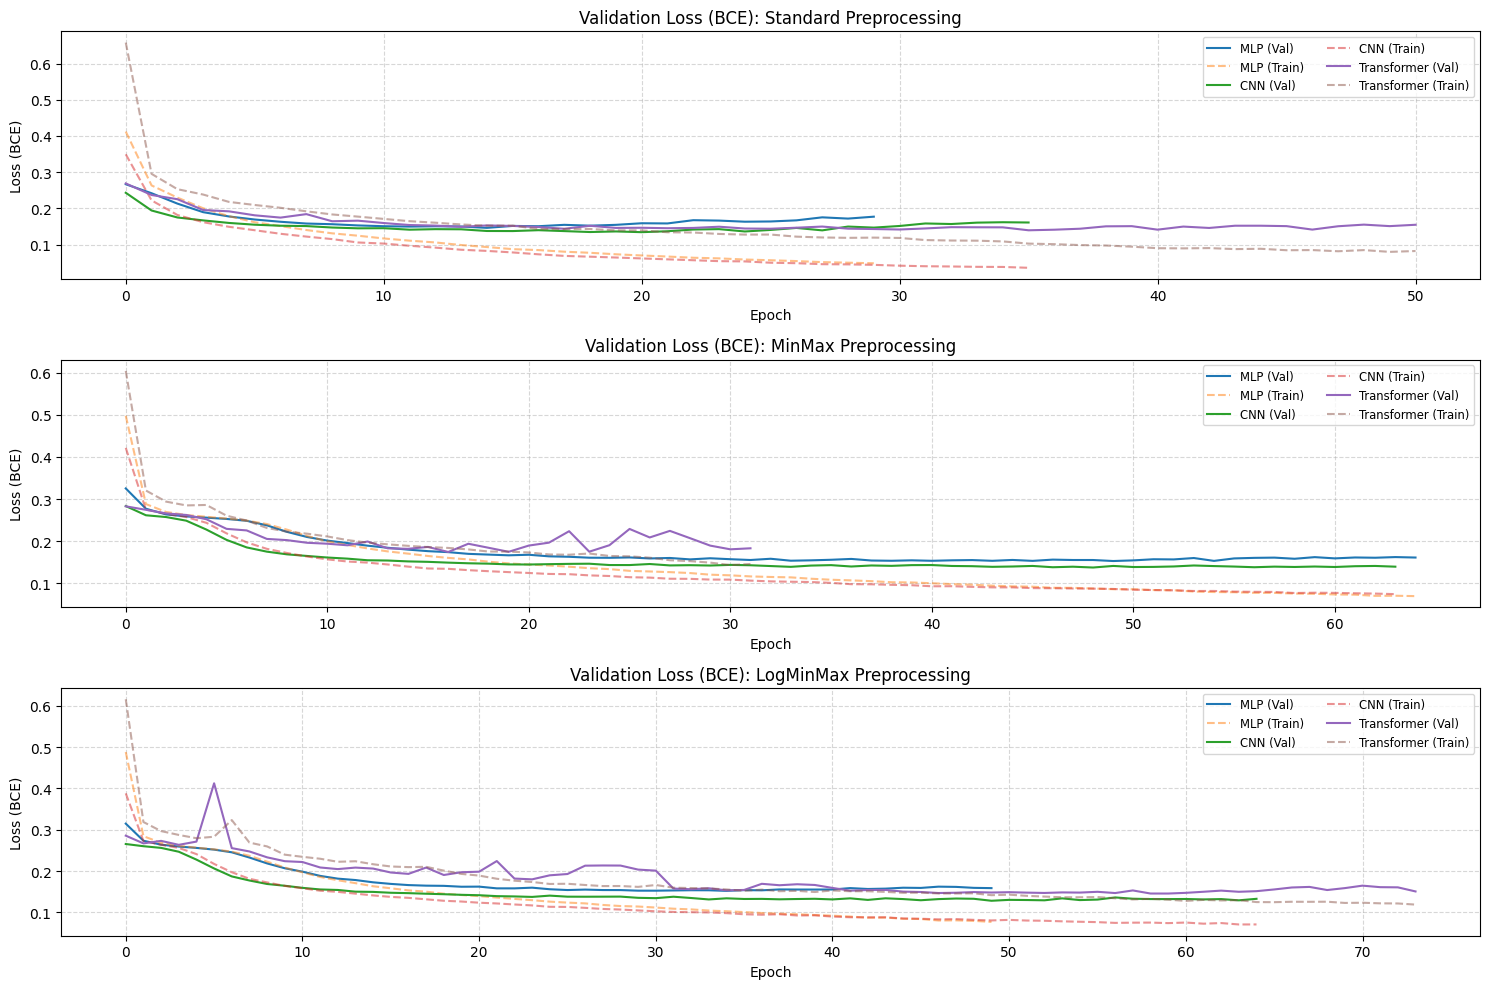

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

plot_idx = 1
for prep_name in preprocessing_strategies.keys():
    plt.subplot(len(preprocessing_strategies), 1, plot_idx)

    for arch_name in architectures.keys():
        key = f"{prep_name}_{arch_name}"
        if key in results:
            history = results[key]['history']

            if history is not None:
                plt.plot(history['val_loss'], label=f"{arch_name} (Val)")
                plt.plot(history['train_loss'], linestyle='--', alpha=0.5, label=f"{arch_name} (Train)")

    plt.title(f"Validation Loss (BCE): {prep_name} Preprocessing")
    # plt.yscale('log')

    plt.xlabel("Epoch")
    plt.ylabel("Loss (BCE)")
    plt.legend(loc='upper right', ncol=2, fontsize='small')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plot_idx += 1

plt.tight_layout()
plt.show()

# Evaluation & Visualization

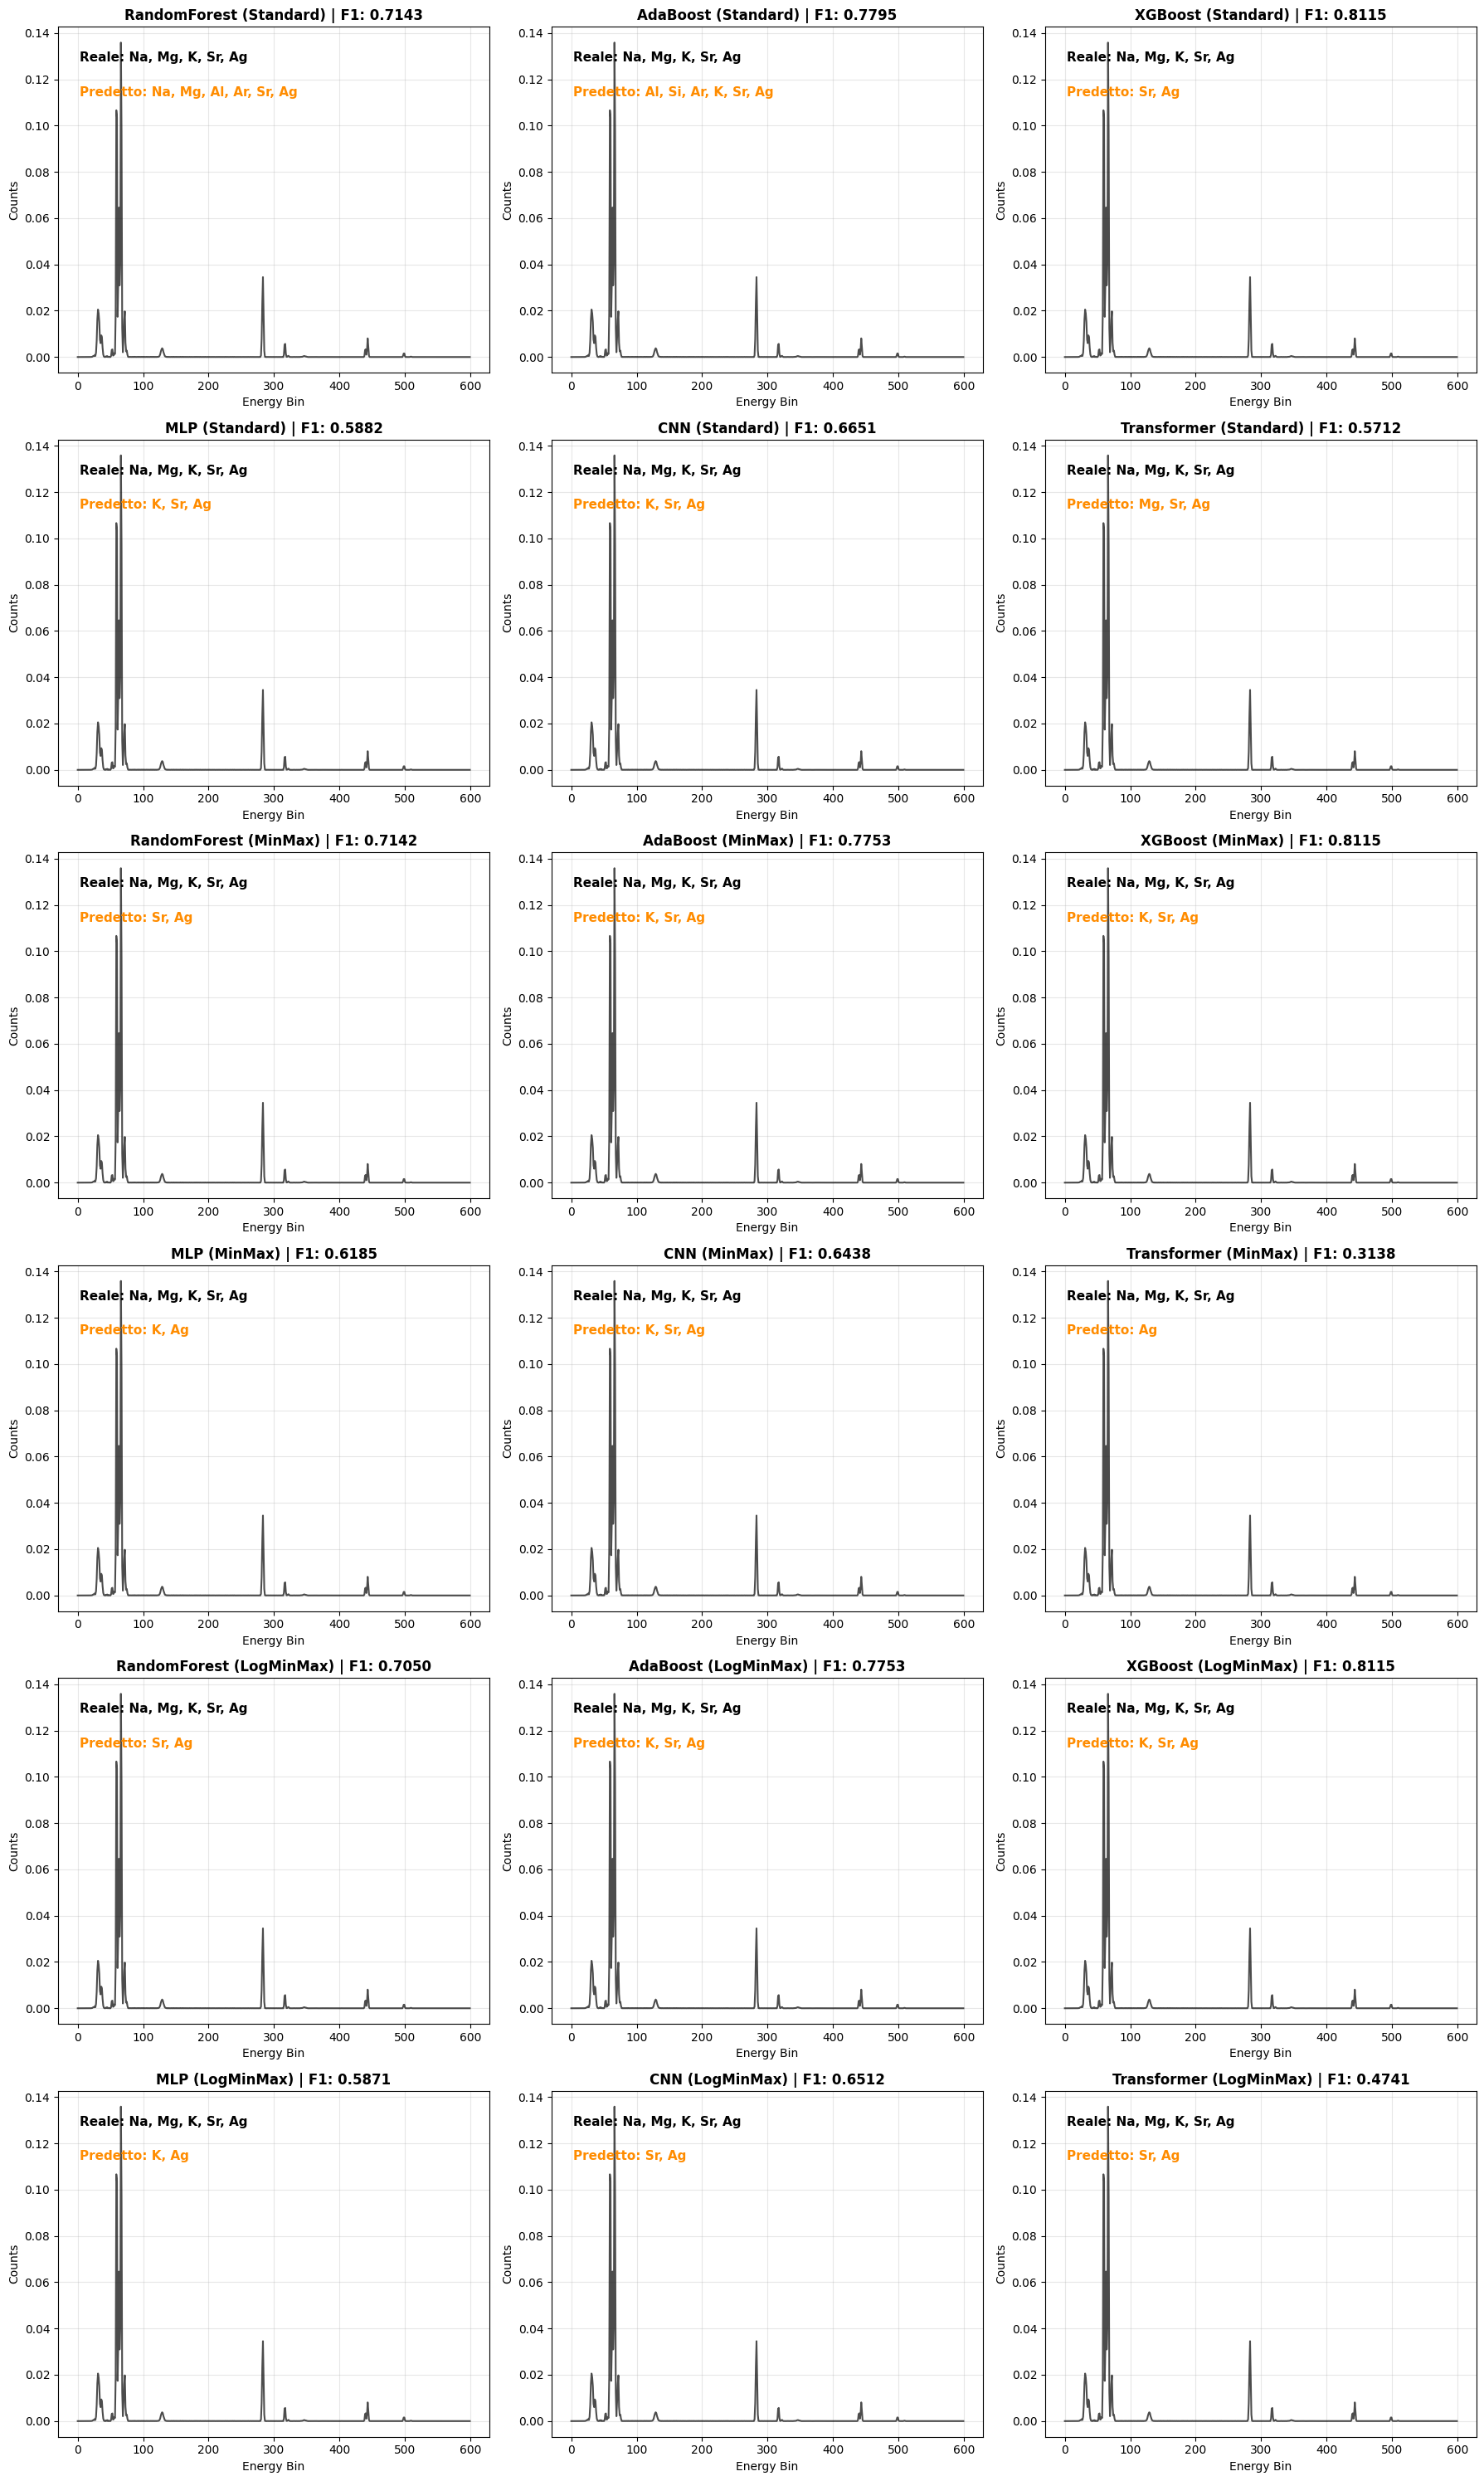

In [14]:
import matplotlib.pyplot as plt
import torch
import math

sample_idx = 0
test_spectrum = X_test[sample_idx:sample_idx+1]
test_labels_true = y_test.iloc[sample_idx]

true_elements = test_labels_true.index[test_labels_true == 1].tolist()
true_text = f"Reale: {', '.join(true_elements)}"

n_models = len(trained_models)
cols = 3
rows = math.ceil(n_models / cols)

plt.figure(figsize=(18, 5 * rows))

for i, key in enumerate(trained_models.keys()):
    model, scaler = trained_models[key]
    prep_name, arch_name = key.split('_')[0], key.split('_')[1]

    scaled_input = scaler.transform(test_spectrum)

    if arch_name in ['RandomForest', 'AdaBoost', 'XGBoost']:
        pred_binary = model.predict(scaled_input)[0]
    else:
        model.eval()
        with torch.no_grad():
            device = next(model.parameters()).device
            tensor_input = torch.FloatTensor(scaled_input).to(device)
            pred_binary = (model(tensor_input).cpu().numpy()[0] > 0.5).astype(int)

    pred_elements = y_test.columns[pred_binary == 1].tolist()
    pred_text = f"Predetto: {', '.join(pred_elements) if pred_elements else 'Nessuno'}"

    if set(true_elements) == set(pred_elements):
        text_color = 'green'
    elif set(true_elements).intersection(pred_elements):
        text_color = 'darkorange'
    else:
        text_color = 'red'

    plt.subplot(rows, cols, i+1)
    plt.plot(test_spectrum[0], color='black', alpha=0.7)

    f1_val = results[key]['f1_score']
    plt.title(f"{arch_name} ({prep_name}) | F1: {f1_val:.4f}", fontsize=12, fontweight='bold')

    plt.text(0.05, 0.90, true_text, transform=plt.gca().transAxes, fontsize=11, fontweight='bold')
    plt.text(0.05, 0.80, pred_text, transform=plt.gca().transAxes, fontsize=11, fontweight='bold', color=text_color)

    plt.xlabel("Energy Bin")
    plt.ylabel("Counts")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparative Results

In [13]:
import pandas as pd

summary_data = []
for key, metrics in results.items():
    parts = key.split('_')
    prep = parts[0]
    arch = parts[1]

    summary_data.append({
        'Preprocessing': prep,
        'Architecture': arch,
        'F1-Score': metrics['f1_score'],
        'Precision': metrics.get('precision', 0.0),
        'Recall': metrics.get('recall', 0.0)
    })

df_results = pd.DataFrame(summary_data).sort_values(by='F1-Score', ascending=False)

print("Model Performance Summary (Best to Worst by F1-Score):")
display(df_results.style.format({
    'F1-Score': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}'
}).background_gradient(subset=['F1-Score'], cmap='viridis'))

Model Performance Summary (Best to Worst by F1-Score):


,Preprocessing,Architecture,F1-Score,Precision,Recall
8,MinMax,XGBoost,0.8115,0.9104,0.7611
2,Standard,XGBoost,0.8115,0.9104,0.7611
14,LogMinMax,XGBoost,0.8115,0.9104,0.7611
1,Standard,AdaBoost,0.7795,0.8524,0.7340
13,LogMinMax,AdaBoost,0.7753,0.8474,0.7307
7,MinMax,AdaBoost,0.7753,0.8474,0.7307
0,Standard,RandomForest,0.7143,0.9765,0.6319
6,MinMax,RandomForest,0.7142,0.9765,0.6298
12,LogMinMax,RandomForest,0.7050,0.9651,0.6276
4,Standard,CNN,0.6651,0.8876,0.5570
